# Baroclinic 3D model

**What this shows:** a 3D SCHISM model that computes temperature and salinity, started
from and forced at its open boundary by an ocean reanalysis.

**Prerequisites:** [Ocean boundaries](ocean_boundaries.ipynb) and
[Tutorial 2: The mesh and the vertical grid](../tutorial/02_mesh_and_vertical_grid.ipynb).

**You will learn:**

- how to set up a baroclinic model: vertical grid, `ibc=0`, temperature and salinity
- how to force the open boundary with 3D currents, temperature and salinity
- how to start the model from an ocean model with a hotstart file
- how to read and plot 3D output

**Data used:** `hgrid.gr3`, `tides/` and `glorys-perth-20230101-05.nc`. The run
needs Docker, takes about five minutes, and is skipped without it.

## Setup

In [1]:
import shutil
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np
import xarray as xr
from rompy.backends import DockerConfig
from rompy.core.data import DataBlob
from rompy.core.source import SourceFile
from rompy.core.time import TimeRange
from rompy.core.types import DatasetCoords
from rompy.logging import config as logging_config
from rompy.model import ModelRun

from rompy_schism.boundary_core import TidalDataset
from rompy_schism.config import SCHISMConfig
from rompy_schism.data import (
    BoundarySetupWithSource,
    HotstartConfig,
    SCHISMData,
    SCHISMDataBoundary,
    SCHISMDataBoundaryConditions,
)
from rompy_schism.grid import SCHISMGrid, VgridGenerator
from rompy_schism.namelists import NML, Param

logging_config.update(level="ERROR")

DATA_DIR = Path("../data")
OUT_DIR = Path("_output") / "baroclinic_3d"
shutil.rmtree(OUT_DIR, ignore_errors=True)
SCHISM_IMAGE = "ghcr.io/rom-py/schism:5.13.0"
ASPECT = 1 / np.cos(np.radians(32))

## 1. The vertical grid

Twelve terrain-following (SZ) levels, concentrated towards the surface.

In [2]:
grid = SCHISMGrid(
    hgrid=DataBlob(source=DATA_DIR / "hgrid.gr3"),
    vgrid=VgridGenerator(vgrid_type="sz", nvrt=12, h_c=10.0, theta_b=0.5, theta_f=3.0),
    drag=0.0025,
)
print(f"3D: {grid.is_3d}, levels: {grid.nvrt}")

3D: True, levels: 12


## 2. The ocean model at the boundary

GLORYS provides everything the open boundary needs, as in
[Ocean boundaries](ocean_boundaries.ipynb), now in 3D. `SCHISMDataBoundary` also
interpolates in the vertical to SCHISM's levels at each boundary node, given the name
of the depth coordinate (`z`).

| Flag | Value | Meaning |
|---|---|---|
| `elev_type` | 5 | tide plus the ocean model's sea level (`elev2D.th.nc`) |
| `vel_type` | 5 | tidal currents plus the ocean model's currents (`uv3D.th.nc`) |
| `temp_type`, `salt_type` | 4 | temperature and salinity from the ocean model (`TEM_3D.th.nc`, `SAL_3D.th.nc`) |

`temp_nudge` and `salt_nudge` (1 by default) set how strongly incoming water is
relaxed to the boundary values.

In [3]:
glorys = SourceFile(uri=DATA_DIR / "glorys-perth-20230101-05.nc")
surface = DatasetCoords(t="time", x="longitude", y="latitude")
profile = DatasetCoords(t="time", x="longitude", y="latitude", z="depth")
ocean = BoundarySetupWithSource(
    elev_type=5,
    vel_type=5,
    temp_type=4,
    salt_type=4,
    elev_source=SCHISMDataBoundary(source=glorys, variables=["zos"], coords=surface),
    vel_source=SCHISMDataBoundary(source=glorys, variables=["uo", "vo"], coords=profile),
    temp_source=SCHISMDataBoundary(source=glorys, variables=["thetao"], coords=profile),
    salt_source=SCHISMDataBoundary(source=glorys, variables=["so"], coords=profile),
)

## 3. Initial conditions

A baroclinic model needs temperature and salinity everywhere at the start.
`HotstartConfig` interpolates them from the same ocean model into `hotstart.nc`, the
file SCHISM starts from. rompy-schism then sets `ihot=1`, which tells SCHISM to read
it.

In [4]:
conditions = SCHISMDataBoundaryConditions(
    tidal_data=TidalDataset(
        tidal_database=DATA_DIR / "tides",
        tidal_model="TPXO9-perth",
        constituents=["M2", "S2", "N2", "K2", "K1", "O1", "P1", "Q1"],
        nodal_corrections=True,
    ),
    default_boundary=ocean,
    hotstart_config=HotstartConfig(enabled=True, temp_var="thetao", salt_var="so"),
)

## 4. Settings and output

- **`ibc=0`**: baroclinic, the default. Temperature and salinity are transported and
  change the density, which drives currents.
- **Output:** water level and depth-averaged velocity (2D), 3D velocity, temperature
  and salinity. That needs 6 scribes: 1 for the 2D variables, 1 for the vertical
  coordinates, 2 for the velocity, 1 each for temperature and salinity.

In [5]:
nml = NML(
    param=Param(
        core={"dt": 120.0, "nspool": 30, "ihfskip": 720},
        schout={
            "iof_hydro__1": 1,
            "iof_hydro__16": 1,
            "iof_hydro__18": 1,  # temperature
            "iof_hydro__19": 1,  # salinity
            "iof_hydro__26": 1,  # 3D velocity
        },
    )
)
config = SCHISMConfig(grid=grid, data=SCHISMData(boundary_conditions=conditions), nml=nml)
print(f"ihot = {config.nml.param.opt.ihot}")

period = TimeRange(start="2023-01-01T00:00", end="2023-01-03T00:00", interval="1h")
modelrun = ModelRun(run_id="baroclinic", period=period, output_dir=OUT_DIR, config=config)
workspace = Path(modelrun())
sorted(p.name for p in workspace.glob("*.nc"))

ihot = 1


['SAL_3D.th.nc', 'TEM_3D.th.nc', 'elev2D.th.nc', 'hotstart.nc', 'uv3D.th.nc']

The initial surface temperature from `hotstart.nc`: warmer water offshore, carried
south by the Leeuwin Current, and cooler water on the inner shelf.

[Text(0.5, 1.0, 'Initial surface temperature'), None]

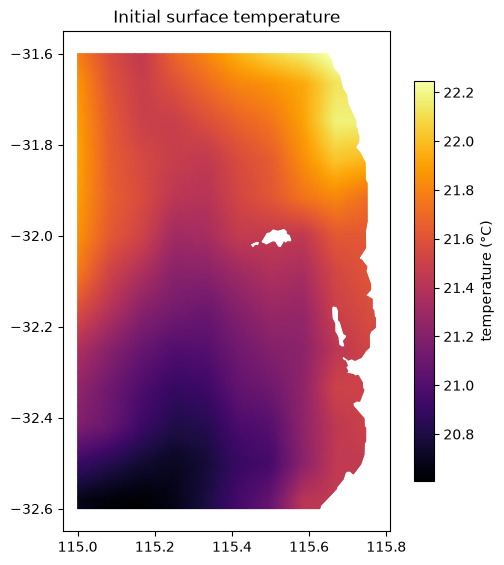

In [6]:
hotstart = xr.open_dataset(workspace / "hotstart.nc")
hgrid = grid.pylibs_hgrid
triangulation = mtri.Triangulation(hgrid.x, hgrid.y, hgrid.elnode[:, :3])
fig, ax = plt.subplots(figsize=(6, 6.5))
tpc = ax.tripcolor(
    triangulation, hotstart.tr_nd[:, -1, 0], cmap="inferno", shading="gouraud"
)
fig.colorbar(tpc, ax=ax, label="temperature (°C)", shrink=0.8)
ax.set(title="Initial surface temperature", aspect=ASPECT)

## 5. Run

10 processes: 4 compute and 6 scribes. The image allows more processes than the
machine has cores.

In [7]:


def docker_available() -> bool:
    """Return True if the Docker daemon can be reached."""
    try:
        return subprocess.run(["docker", "info"], capture_output=True).returncode == 0
    except FileNotFoundError:
        return False


def run_completed(workspace: Path) -> bool:
    """Check SCHISM's log: SCHISM exits with success even when it stops on an error."""
    mirror = workspace / "outputs" / "mirror.out"
    if mirror.exists() and "Run completed successfully" in mirror.read_text():
        return True
    fatal = workspace / "outputs" / "fatal.error"
    print(fatal.read_text() if fatal.exists() else "SCHISM did not finish")
    return False


if docker_available():
    backend = DockerConfig(
        image=SCHISM_IMAGE, executable="schism 6", mpiexec="mpirun", cpu=10
    )
    modelrun.run(backend, workspace_dir=workspace)
completed = run_completed(workspace)
print("SCHISM finished" if completed else "SCHISM did not finish")

SCHISM finished


## 6. 3D output

Each 3D variable is in its own files, with a value at each node and level;
`zCoordinates` gives the height of each level. Surface and bottom temperature at the
end of the run: the surface is warm everywhere, within 2 °C, while the bottom follows
the depth, from over 20 °C on the shelf to about 5 °C at the foot of the slope.

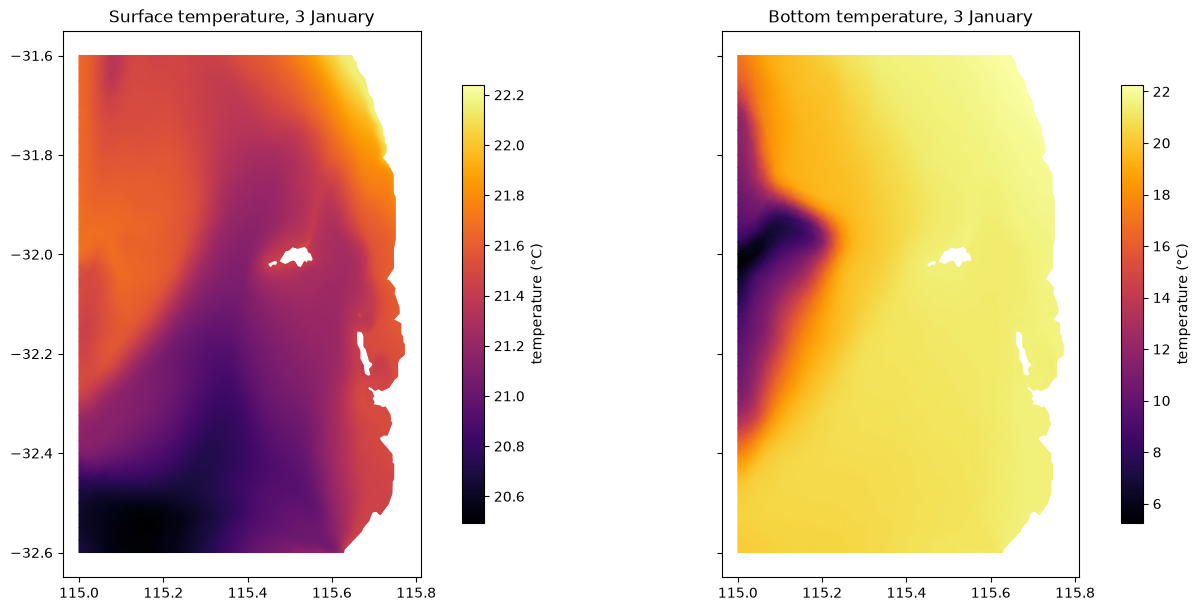

In [8]:
def open_output(name: str) -> xr.Dataset:
    """All stacks of one SCHISM output variable."""
    return xr.open_mfdataset(
        sorted((workspace / "outputs").glob(f"{name}_*.nc")),
        data_vars="minimal", coords="minimal", compat="override",
    )  # fmt: skip


if completed:
    temperature = open_output("temperature").temperature
    zcoords = open_output("zCoordinates").zCoordinates
    out2d = open_output("out2d")
    bottom = out2d.bottom_index_node.values - 1
    last = temperature.isel(time=-1).values
    nodes = np.arange(last.shape[0])
    fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True, layout="constrained")
    for ax, (name, values) in zip(
        axes, [("surface", last[:, -1]), ("bottom", last[nodes, bottom])]
    ):
        tpc = ax.tripcolor(triangulation, values, cmap="inferno", shading="gouraud")
        fig.colorbar(tpc, ax=ax, label="temperature (°C)", shrink=0.8)
        ax.set(title=f"{name.capitalize()} temperature, 3 January", aspect=ASPECT)

A section across the shelf west of Fremantle, from the level heights and the
temperature at the nearest node to each point. The water is well mixed on the shallow
shelf and stratified offshore, with warm water over cooler water below.

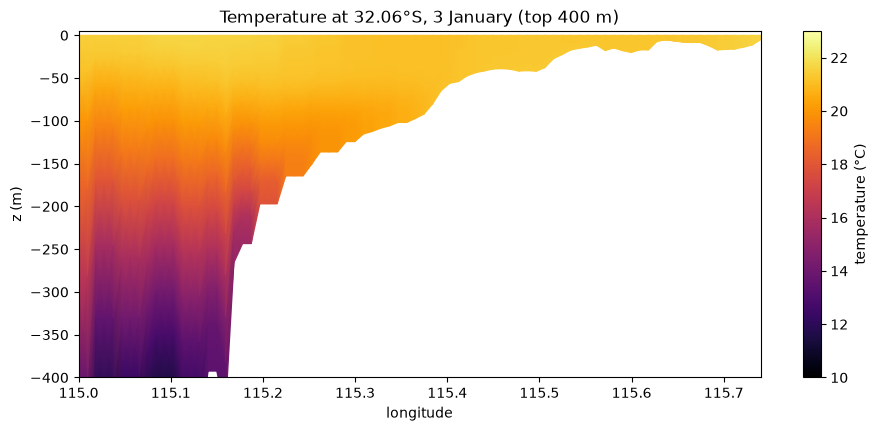

In [9]:
if completed:
    x, y = hgrid.x, hgrid.y
    lons = np.linspace(115.0, 115.74, 80)
    section_nodes = [np.argmin((x - lon) ** 2 + (y + 32.06) ** 2) for lon in lons]
    z = zcoords.isel(time=-1).values[section_nodes]
    t = last[section_nodes]
    fig, ax = plt.subplots(figsize=(11, 4.5))
    mesh = ax.pcolormesh(
        np.broadcast_to(lons[:, None], z.shape), z, t, cmap="inferno", shading="gouraud",
        vmin=10, vmax=23,
    )  # fmt: skip
    fig.colorbar(mesh, ax=ax, label="temperature (°C)")
    ax.set(
        ylim=(-400, 5), xlabel="longitude", ylabel="z (m)",
        title="Temperature at 32.06°S, 3 January (top 400 m)",
    )  # fmt: skip

## Summary

- A baroclinic model needs a 3D vertical grid, `ibc=0`, and temperature and salinity
  at the start and at open boundaries.
- `SCHISMDataBoundary` with a depth coordinate interpolates an ocean model to the
  boundary nodes and levels; types 4 and 5 read the resulting files.
- `HotstartConfig` builds `hotstart.nc` from the ocean model, and rompy-schism sets
  `ihot=1` to start from it.
- Each 3D variable needs its own scribe (two for vectors), and each is written to its
  own files, with `zCoordinates` for the level heights.